In [1]:
# core
import numpy as np
import pandas as pd

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils import class_weight

# metrics
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# visualization
import matplotlib.pyplot as plt

# saving
import pickle

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

# drop irrelevant columns
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

In [3]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [4]:
# categorical columns
categorical_cols = ["Geography", "Gender"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# encoders
label_encoder = LabelEncoder()
X["Gender"] = label_encoder.fit_transform(X["Gender"])

# one-hot for geography
ct = ColumnTransformer(
    transformers=[
        ("geo", OneHotEncoder(handle_unknown="ignore"), ["Geography"])
    ],
    remainder="passthrough"
)

X = ct.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

In [8]:
model = Sequential([
    Dense(128, activation="relu", input_dim=X_train.shape[1]),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

c:\Users\admin\Documents\CCP\Customer-Churn-Prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6253 - loss: 0.6341 - val_accuracy: 0.7925 - val_loss: 0.5255
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - accuracy: 0.6978 - loss: 0.5599 - val_accuracy: 0.8006 - val_loss: 0.4449
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7336 - loss: 0.5294 - val_accuracy: 0.7750 - val_loss: 0.4565
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7495 - loss: 0.5162 - val_accuracy: 0.7713 - val_loss: 0.4607
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - accuracy: 0.7550 - loss: 0.5014 - val_accuracy: 0.7925 - val_loss: 0.4318
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7645 - loss: 0.4931 - val_accuracy: 0.7812 - val_loss: 0.4510
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - accuracy: 0.7575 - loss: 0.4964 - val_accuracy: 0.7975 - val_loss: 0.4242
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7694 - loss: 0.4818 - va

In [10]:
# probabilities
y_probs = model.predict(X_test)

# threshold tuning
threshold = 0.4
y_pred = (y_probs > threshold).astype(int)

# metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_probs))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.70      0.80      1593
           1       0.41      0.81      0.55       407

    accuracy                           0.72      2000
   macro avg       0.67      0.76      0.67      2000
weighted avg       0.83      0.72      0.75      2000

ROC-AUC Score: 0.85620905959889
Confusion Matrix:
 [[1118  475]
 [  76  331]]


In [12]:
model.save("churn_model.h5")

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("encoder.pkl", "wb") as f:
    pickle.dump(ct, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

c:\Users\admin\Documents\CCP\Customer-Churn-Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PermutationExplainer explainer: 101it [00:13,  2.67it/s]                         


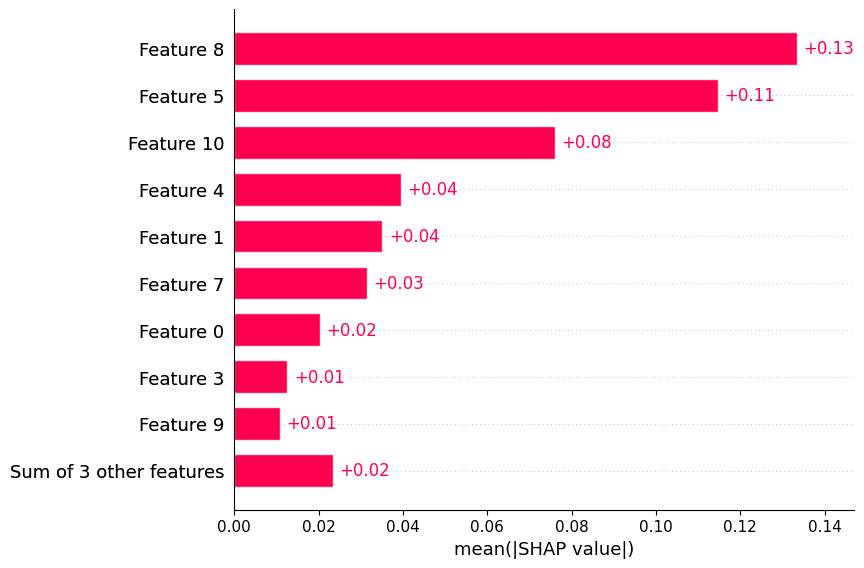

In [ ]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)